In [6]:
# Install & import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
# Load CSV
df = pd.read_csv("../data/Original_Flight_Data.csv")

# Quick overview
print(df.head())
print(df.info())
print(df['binary_delay_dep'].value_counts())
print(df['delay_class_dep'].value_counts())

  id             airline   origin origin_code destination destination_code  \
0  1  SriLankan Airlines  Colombo         CMB      Mumbai              BOM   
1  2  SriLankan Airlines  Colombo         CMB      Mumbai              BOM   
2  3  SriLankan Airlines  Colombo         CMB      Mumbai              BOM   
3  4  SriLankan Airlines  Colombo         CMB      Mumbai              BOM   
4  5  SriLankan Airlines  Colombo         CMB      Mumbai              BOM   

     route aircraft_type scheduled_depature_time actual_depature_time  ...  \
0  CMB_BOM          A21N         12/1/2025 23:40       12/2/2025 1:44  ...   
1  CMB_BOM          A332        11/30/2025 23:40       12/1/2025 2:04  ...   
2  CMB_BOM          A21N         11/30/2025 8:28      11/30/2025 8:28  ...   
3  CMB_BOM          A20N        11/29/2025 23:40                    0  ...   
4  CMB_BOM          A320        11/28/2025 23:40                    0  ...   

  is_short_haul route_avg_delay  route_delay_rate  airline_avg

In [15]:
# Encode categorical features
# Identify categorical columns

drop_cols = [
    'id', 'dep_date_only',
    'actual_depature_time', 'actual_arrival_time',
    'binary_delay_arr', 'delay_class_dep', 'delay_class_arr',
    'departure_delay_min', 'arrival_delay_min', 'delay_ratio','delay_class_dep'
]
df = df.drop(columns=drop_cols)

# 3️⃣ Encode categorical / object columns
categorical_cols = ['airline', 'destination', 'route', 'aircraft_type',
                    'origin', 'origin_code', 'destination_code',
                    'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# 4️⃣ Convert time columns to numeric
for col in ['scheduled_depature_time', 'scheduled_arrival_time']:
    df[col] = pd.to_datetime(df[col], format='%H:%M', errors='coerce')
    df[col] = df[col].dt.hour * 60 + df[col].dt.minute
    df[col] = df[col].fillna(0)

In [21]:
# 5️⃣ Define Features and Target
X = df.drop(columns=['binary_delay_dep'])
y = df['binary_delay_dep']

In [22]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [26]:
# Binary delay model
rf_delay = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)
rf_delay.fit(X_train, y_train)
y_pred_delay = rf_delay.predict(X_test)
print("Binary Delay Accuracy:", accuracy_score(y_test, y_pred_delay))
print(classification_report(y_test, y_pred_delay))

# Delay class model
rf_class = RandomForestClassifier(n_estimators=500, max_depth=12, random_state=42)
rf_class.fit(X_train, y_train)
y_pred_class = rf_class.predict(X_test)
print("Delay Class Accuracy:", accuracy_score(y_test, y_pred_class))
print(classification_report(y_test, y_pred_class))


Binary Delay Accuracy: 0.7278318810866222
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1303
           1       0.64      0.42      0.51       648

    accuracy                           0.73      1951
   macro avg       0.70      0.65      0.66      1951
weighted avg       0.71      0.73      0.71      1951

Delay Class Accuracy: 0.7278318810866222
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      1303
           1       0.64      0.42      0.51       648

    accuracy                           0.73      1951
   macro avg       0.70      0.65      0.66      1951
weighted avg       0.71      0.73      0.71      1951



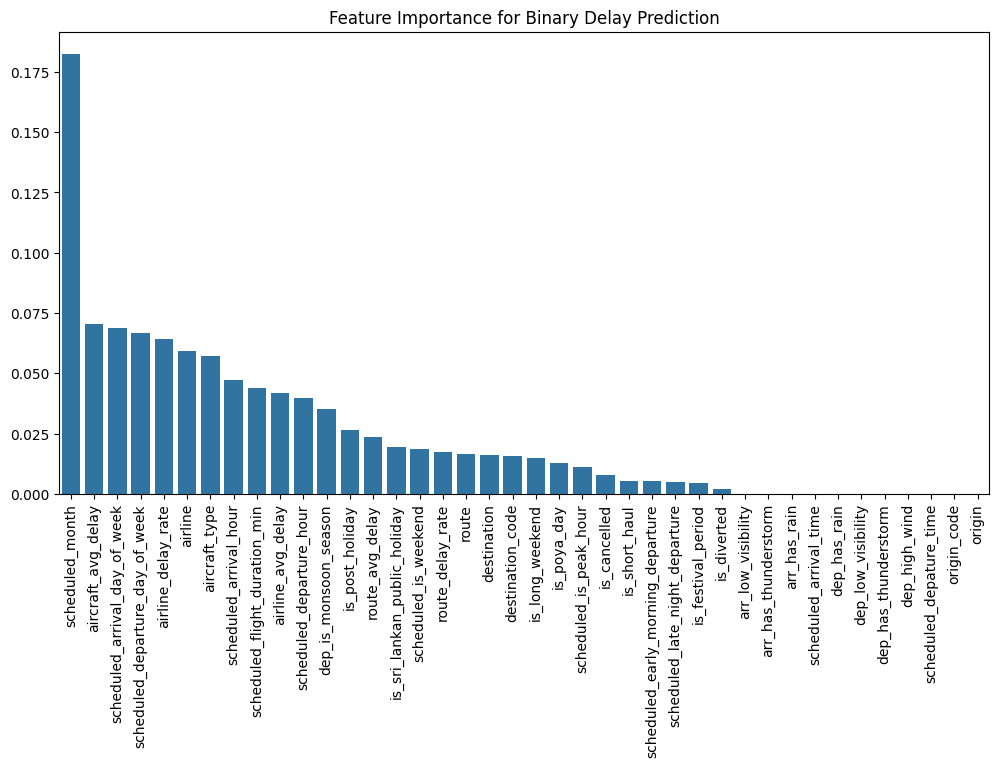

In [28]:
# Binary delay feature importance
importances = rf_delay.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=[X.columns[i] for i in indices], y=importances[indices])
plt.xticks(rotation=90)
plt.title("Feature Importance for Binary Delay Prediction")
plt.show()


In [31]:
# Example new flight (replace with real values)
new_flight = np.array([[df[col].iloc[0] for col in X.columns]])  # using first row as example

# Scale
new_flight_scaled = scaler.transform(new_flight)

# Predict binary delay
delay_prob = rf_delay.predict_proba(new_flight_scaled)[0][1]
delay_pred = (delay_prob > 0.5).astype(int)

# Predict delay class
delay_class_pred = rf_class.predict(new_flight_scaled)[0]

print(f"Predicted Delay: {delay_pred} (Probability: {delay_prob*100:.2f}%)")
print(f"Predicted Delay Class: {delay_class_pred}")


Predicted Delay: 1 (Probability: 72.17%)
Predicted Delay Class: 1


C:\Users\L13\anaconda3\envs\flight_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\L13\anaconda3\envs\flight_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
C:\Users\L13\anaconda3\envs\flight_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
